In [1]:
# on importe les fichiers pour un match

import pandas as pd

data_match = pd.read_csv("Sample_Game_1_RawEventsData.csv")
data_match.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47


In [2]:
# les fichiers de position des joueurs sur le terrain

data_positions_home = pd.read_csv("Sample_Game_1_RawTrackingData_Home_Team.csv", skiprows=2)
data_positions_home.head()

,Period,Frame,Time [s],Player11,Unnamed: 4,Player1,Unnamed: 6,Player2,Unnamed: 8,Player3,...,Player10,Unnamed: 24,Player12,Unnamed: 26,Player13,Unnamed: 28,Player14,Unnamed: 30,Ball,Unnamed: 32
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


In [3]:
def rename_tracking_columns(df):
    new_cols = []
    skip_first = 3  # Period, Frame, Time
    
    # Colonnes fixes
    new_cols.extend(df.columns[:skip_first])
    
    # Colonnes joueurs / ballon
    cols = df.columns[skip_first:]
    
    # On itère 2 par 2 : [Player11, Unnamed:4], [Player1, Unnamed:6], etc.
    for i in range(0, len(cols), 2):
        col_x = cols[i]
        col_y = cols[i+1]
        
        base_name = col_x  # ex: "Player11", "Player1", etc.
        
        # nouveau nom = Player11_X et Player11_Y
        new_cols.append(f"{base_name}_X")
        new_cols.append(f"{base_name}_Y")
    
    df.columns = new_cols
    return df
data_positions_home = rename_tracking_columns(data_positions_home)
data_positions_home.head()

,Period,Frame,Time [s],Player11_X,Player11_Y,Player1_X,Player1_Y,Player2_X,Player2_Y,Player3_X,...,Player10_X,Player10_Y,Player12_X,Player12_Y,Player13_X,Player13_Y,Player14_X,Player14_Y,Ball_X,Ball_Y
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


In [4]:
# pareil pour l'équipe visiteuse

data_positions_away = pd.read_csv("Sample_Game_1_RawTrackingData_Away_Team.csv", skiprows=2)
data_positions_away = rename_tracking_columns(data_positions_away)
data_positions_away.head()

,Period,Frame,Time [s],Player25_X,Player25_Y,Player15_X,Player15_Y,Player16_X,Player16_Y,Player17_X,...,Player24_X,Player24_Y,Player26_X,Player26_Y,Player27_X,Player27_Y,Player28_X,Player28_Y,Ball_X,Ball_Y
0,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.90377,0.47463,0.58351,0.20868,0.67640,0.46762,0.67279,...,0.37756,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.90324,0.47464,0.58291,0.21039,0.67599,0.46769,0.67253,...,0.37663,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


# Création de l’indicateur de domination

In [ ]:
import pandas as pd
import numpy as np

# --- Paramètres : chemins fichiers ---
home_path = "Sample_Game_1_RawTrackingData_Home_Team.csv"
away_path = "Sample_Game_1_RawTrackingData_Away_Team.csv"

# --- Fonction utilitaire : lire et renommer les colonnes d'un fichier tracking ---
def load_and_rename_tracking(path, team_label, skiprows=2):
    """
    Charge un fichier tracking et renomme les colonnes joueur X/Y en ajoutant le préfixe team_label.
    - skiprows : saute les 2 premières lignes d'entête comme discuté.
    - team_label : "Home" ou "Away" (sera préfixé aux colonnes players).
    Retourne un DataFrame avec colonnes ['Period','Frame','Time [s]', '<team>_Player11_X', '<team>_Player11_Y', ... , '<team>_Ball_X', '<team>_Ball_Y']
    """
    df = pd.read_csv(path, skiprows=skiprows)
    base_cols = list(df.columns)
    prefix_keep = base_cols[:3]
    other = base_cols[3:]
    
    new_cols = []
    new_cols.extend(prefix_keep)
    
    for i in range(0, len(other), 2):
        col_x = other[i]
        col_y = other[i+1] if i+1 < len(other) else None
        
        # construire un nom de base propre à partir de col_x (ex: "Player11" ou "Ball")
        base_name = str(col_x).strip()
        # normaliser base_name (retirer espaces, Unnamed etc.)
        if base_name.lower().startswith("unnamed") or base_name == "":
            base_name = f"unknown{i//2}"
        
        # préfixer par team label pour éviter collision
        new_x = f"{team_label}_{base_name}_X"
        new_cols.append(new_x)
        
        if col_y is not None:
            new_y = f"{team_label}_{base_name}_Y"
            new_cols.append(new_y)
        else:
            # si pas de colonne Y, ajouter un placeholder
            new_cols.append(f"{team_label}_{base_name}_Y")
    
    df.columns = new_cols
    return df

# --- Charger Home & Away ---
tracking_home = load_and_rename_tracking(home_path, "Home", skiprows=2)
tracking_away = load_and_rename_tracking(away_path, "Away", skiprows=2)

# --- Préparer pour merge_asof : trier par Period puis Time [s] ---
tracking_home = tracking_home.sort_values(['Period', 'Time [s]']).reset_index(drop=True)
tracking_away = tracking_away.sort_values(['Period', 'Time [s]']).reset_index(drop=True)

# --- fusionner par période en utilisant merge_asof (on aligne les times les plus proches)
# merge_asof ne supporte pas la clé 'Period' directement : on boucle par Period pour être sûr
periods = sorted(set(tracking_home['Period'].unique()).union(tracking_away['Period'].unique()))

merged_frames = []
for per in periods:
    h = tracking_home[tracking_home['Period'] == per].copy()
    a = tracking_away[tracking_away['Period'] == per].copy()
    
    if h.empty and a.empty:
        continue
    if h.empty:
        # aucune ligne home → ajouter away directement (mais préfixé)
        merged = a
        merged_frames.append(merged)
        continue
    if a.empty:
        merged = h
        merged_frames.append(merged)
        continue
    
    # merge_asof requires sorted by time
    merged = pd.merge_asof(
        h, a,
        on='Time [s]',
        by='Period',
        direction='nearest',
        suffixes=('_home','_away')
    )
    merged_frames.append(merged)

# concatérer tous les periods
tracking_all = pd.concat(merged_frames, ignore_index=True, sort=False)

# Chercher colonnes ball:
ball_cols = [c for c in tracking_all.columns if 'Ball' in c]
# Si tu veux renommer Home_Ball_X etc en unified Ball_X/Ball_Y, fais :
# mais attention aux collisions si Ball présent dans les deux fichiers — ici on garde les deux s'ils existent.
# Exemple : si seul home a Ball, on peut copier Home_Ball_* -> Ball_*
if any(c.startswith('Home_') and 'Ball' in c for c in tracking_all.columns) and not any(c.startswith('Ball_') for c in tracking_all.columns):
    # créer Ball_X / Ball_Y à partir Home_Ball_X / Home_Ball_Y
    if 'Home_Ball_X' in tracking_all.columns:
        tracking_all['Ball_X'] = tracking_all['Home_Ball_X']
    if 'Home_Ball_Y' in tracking_all.columns:
        tracking_all['Ball_Y'] = tracking_all['Home_Ball_Y']
# idem pour Away_Ball_*
if 'Away_Ball_X' in tracking_all.columns and 'Ball_X' not in tracking_all.columns:
    tracking_all['Ball_X'] = tracking_all['Away_Ball_X']
if 'Away_Ball_Y' in tracking_all.columns and 'Ball_Y' not in tracking_all.columns:
    tracking_all['Ball_Y'] = tracking_all['Away_Ball_Y']

# --- index propre et aperçu ---
tracking_all = tracking_all.reset_index(drop=True)
print("Merged tracking shape:", tracking_all.shape)
print("Columns sample:", tracking_all.columns[:20])

# --- Fonction utilitaire pour obtenir la frame la plus proche d'un time donné (utiliser après merge) ---
def get_closest_frame(tracking_df, period, time_s):
    """
    Retourne la ligne tracking la plus proche pour la période et le temps fournis.
    """
    dfp = tracking_df[tracking_df['Period'] == period]
    if dfp.empty:
        return None
    idx = (dfp['Time [s]'] - time_s).abs().idxmin()
    return dfp.loc[idx]

tracking_all.head()


Merged tracking shape: (145006, 66)
Columns sample: Index(['Period', 'Frame_home', 'Time [s]', 'Home_Player11_X',
       'Home_Player11_Y', 'Home_Player1_X', 'Home_Player1_Y', 'Home_Player2_X',
       'Home_Player2_Y', 'Home_Player3_X', 'Home_Player3_Y', 'Home_Player4_X',
       'Home_Player4_Y', 'Home_Player5_X', 'Home_Player5_Y', 'Home_Player6_X',
       'Home_Player6_Y', 'Home_Player7_X', 'Home_Player7_Y', 'Home_Player8_X'],
      dtype='object')


,Period,Frame_home,Time [s],Home_Player11_X,Home_Player11_Y,Home_Player1_X,Home_Player1_Y,Home_Player2_X,Home_Player2_Y,Home_Player3_X,...,Away_Player26_X,Away_Player26_Y,Away_Player27_X,Away_Player27_Y,Away_Player28_X,Away_Player28_Y,Away_Ball_X,Away_Ball_Y,Ball_X,Ball_Y
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570,0.55512,0.40570


In [6]:
events = pd.read_csv("Sample_Game_1_RawEventsData.csv")

# Garder uniquement les passes
passes = events[events['Type'] == "PASS"].copy()

# On garde les colonnes importantes
passes = passes[['Period', 'Start Time [s]', 'End Time [s]',
                 'Start X', 'Start Y',
                 'End X', 'End Y',
                 'From', 'To']]


In [7]:
passes.head()

,Period,Start Time [s],End Time [s],Start X,Start Y,End X,End Y,From,To
1,1,0.04,0.12,0.45,0.39,0.55,0.43,Player19,Player21
2,1,0.12,0.68,0.55,0.43,0.58,0.21,Player21,Player15
3,1,1.80,2.44,0.55,0.19,0.45,0.31,Player15,Player19
4,1,3.08,3.84,0.45,0.32,0.49,0.47,Player19,Player21
5,1,7.64,8.68,0.40,0.73,0.32,0.98,Player21,Player22


In [8]:
pass_rows = []

for i, row in passes.iterrows():
    per  = row['Period']
    t0   = row['Start Time [s]']
    t1   = row['End Time [s]']

    # frame de début
    start_frame = get_closest_frame(tracking_all, per, t0)
    # frame de fin
    end_frame   = get_closest_frame(tracking_all, per, t1)

    pass_rows.append({
        "Period" : per,
        "Start Time" : t0,
        "End Time" : t1,
        "Start X" : row["Start X"],
        "Start Y" : row["Start Y"],
        "End X"   : row["End X"],
        "End Y"   : row["End Y"],
        "From"    : row["From"],
        "To"      : row["To"],

        # tracking : frames complètes
        "tracking_start" : start_frame,
        "tracking_end"   : end_frame
    })

pass_with_tracking = pd.DataFrame(pass_rows)


In [ ]:
sample = pass_with_tracking.iloc[0]["tracking_start"]

home_players = sorted({
    k.replace("_X","").replace("_Y","")
    for k in sample.keys()
    if k.startswith("Home_Player")
})

away_players = sorted({
    k.replace("_X","").replace("_Y","")
    for k in sample.keys()
    if k.startswith("Away_Player")
})

Home players: ['Home_Player1', 'Home_Player10', 'Home_Player11', 'Home_Player12', 'Home_Player13', 'Home_Player14', 'Home_Player2', 'Home_Player3', 'Home_Player4', 'Home_Player5', 'Home_Player6', 'Home_Player7', 'Home_Player8', 'Home_Player9']
Away players: ['Away_Player15', 'Away_Player16', 'Away_Player17', 'Away_Player18', 'Away_Player19', 'Away_Player20', 'Away_Player21', 'Away_Player22', 'Away_Player23', 'Away_Player24', 'Away_Player25', 'Away_Player26', 'Away_Player27', 'Away_Player28']


In [10]:
def which_team(row):
    from_player = row['From']
    # vérifier si le joueur est dans Home ou Away
    if any(from_player in p for p in home_players):
        return "Home"
    elif any(from_player in p for p in away_players):
        return "Away"
    else:
        return "Unknown"

In [11]:
pass_with_tracking["Team"] = pass_with_tracking.apply(which_team, axis=1)

In [12]:
def goal_position(team, period):
    """
    Renvoie la position du but adverse pour l'équipe en possession.
    Coordonnées normalisées : X ∈ [0,1], Y ∈ [0,1]
    """
    # Home attaque → droite en 1ère MT, gauche en 2e
    if team == "Home":
        return np.array([1, 0.5]) if period == 1 else np.array([0, 0.5])
    
    # Away attaque → gauche en 1ère MT, droite en 2e
    else:
        return np.array([0, 0.5]) if period == 1 else np.array([1, 0.5])

In [13]:
def progression_toward_goal(start_pos, end_pos, attacking_goal):
    start_dist = np.linalg.norm(attacking_goal - start_pos)
    end_dist   = np.linalg.norm(attacking_goal - end_pos)
    return start_dist - end_dist

In [14]:
def angle_toward_goal(start_pos, end_pos, attacking_goal):
    v_pass = end_pos - start_pos
    v_goal = attacking_goal - start_pos
    dot = np.dot(v_pass, v_goal)
    norm = np.linalg.norm(v_pass) * np.linalg.norm(v_goal)
    return dot / (norm + 1e-6)


In [15]:
def distance_to_goal(end_pos, attacking_goal):
    return np.linalg.norm(attacking_goal - end_pos)


In [16]:
def pressure_features(carrier_pos, opponent_positions):
    dists = np.linalg.norm(opponent_positions - carrier_pos, axis=1)
    mindist = None
    for d in dists:
        if isinstance(d, (int, float)):
            if mindist is None or d < mindist:
                mindist = d
    return (
        mindist,
        (dists < 0.02).sum(),
        (dists < 0.06).sum()
    )

In [17]:
def is_line_breaking(receiving_x, def_line_x, attacking_goal_x):
    if attacking_goal_x == 1:
        return receiving_x > def_line_x
    else:
        return receiving_x < def_line_x


In [18]:
def pass_speed(start_pos, end_pos, t_start, t_end):
    dist = np.linalg.norm(end_pos - start_pos)
    dt = max(t_end - t_start, 0.01)
    return dist / dt

In [19]:
def opponents_eliminated(
    carrier_pos_start,
    receiver_pos_end,
    opponent_positions_start,
    opponent_positions_end,
    attacking_goal_x
):
    """
    Calcule le nombre d'adversaires éliminés par la passe.
    """

    # On récupère les X adverses en ignorant les NaN
    opp_start_x = np.array([p[0] for p in opponent_positions_start 
                            if isinstance(p[0], (int, float)) and np.isfinite(p[0])])
    
    opp_end_x = np.array([p[0] for p in opponent_positions_end 
                          if isinstance(p[0], (int, float)) and np.isfinite(p[0])])

    # Si quelque chose manque → on renvoie 0
    if len(opp_start_x) == 0 or len(opp_end_x) == 0:
        return 0

    # On extrait les X du porteur & receveur
    x_carrier = carrier_pos_start[0]
    x_receiver = receiver_pos_end[0]

    # Attaque → droite : x plus grand = plus proche du but
    if attacking_goal_x == 1:
        before = opp_start_x > x_carrier
        after  = opp_end_x < x_receiver

    # Attaque → gauche : x plus petit = plus proche du but
    else:
        before = opp_start_x < x_carrier
        after  = opp_end_x > x_receiver

    # Nombre de joueurs éliminés : ceux qui étaient devant mais ne le sont plus
    eliminated = np.logical_and(before, after).sum()

    return int(eliminated)


In [20]:
def extract_player_lists(tracking_sample):
    cols = tracking_sample.keys()

    home_players = sorted({
        c.replace("_X", "") for c in cols
        if c.startswith("Home_Player") and c.endswith("_X")
    })

    away_players = sorted({
        c.replace("_X", "") for c in cols
        if c.startswith("Away_Player") and c.endswith("_X")
    })

    return home_players, away_players

tracking_sample = pass_with_tracking.iloc[0]["tracking_start"]
home_players, away_players = extract_player_lists(tracking_sample)

home_players, away_players


(['Home_Player1',
  'Home_Player10',
  'Home_Player11',
  'Home_Player12',
  'Home_Player13',
  'Home_Player14',
  'Home_Player2',
  'Home_Player3',
  'Home_Player4',
  'Home_Player5',
  'Home_Player6',
  'Home_Player7',
  'Home_Player8',
  'Home_Player9'],
 ['Away_Player15',
  'Away_Player16',
  'Away_Player17',
  'Away_Player18',
  'Away_Player19',
  'Away_Player20',
  'Away_Player21',
  'Away_Player22',
  'Away_Player23',
  'Away_Player24',
  'Away_Player25',
  'Away_Player26',
  'Away_Player27',
  'Away_Player28'])

In [21]:
pass_with_tracking["home_players"] = [home_players] * len(pass_with_tracking)
pass_with_tracking["away_players"] = [away_players] * len(pass_with_tracking)
pass_with_tracking.head()

,Period,Start Time,End Time,Start X,Start Y,End X,End Y,From,To,tracking_start,tracking_end,Team,home_players,away_players
0,1,0.04,0.12,0.45,0.39,0.55,0.43,Player19,Player21,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
1,1,0.12,0.68,0.55,0.43,0.58,0.21,Player21,Player15,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
2,1,1.80,2.44,0.55,0.19,0.45,0.31,Player15,Player19,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
3,1,3.08,3.84,0.45,0.32,0.49,0.47,Player19,Player21,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
4,1,7.64,8.68,0.40,0.73,0.32,0.98,Player21,Player22,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."


In [22]:
def map_event_player_to_tracking(player_id):
    """
    Convertit 'Player23' → 'Away_Player23'
    et 'Player7' → 'Home_Player7'
    """
    # extraire juste le numéro
    num = int(player_id.replace("Player", ""))

    if 1 <= num <= 14:
        return f"Home_Player{num}"
    elif 15 <= num <= 28:
        return f"Away_Player{num}"
    else:
        raise ValueError(f"Numéro de joueur invalide : {player_id}")


In [23]:
pass_with_tracking.head()

,Period,Start Time,End Time,Start X,Start Y,End X,End Y,From,To,tracking_start,tracking_end,Team,home_players,away_players
0,1,0.04,0.12,0.45,0.39,0.55,0.43,Player19,Player21,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
1,1,0.12,0.68,0.55,0.43,0.58,0.21,Player21,Player15,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
2,1,1.80,2.44,0.55,0.19,0.45,0.31,Player15,Player19,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
3,1,3.08,3.84,0.45,0.32,0.49,0.47,Player19,Player21,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."
4,1,7.64,8.68,0.40,0.73,0.32,0.98,Player21,Player22,Period 1.00000 Frame_home ...,Period 1.00000 Frame_home ...,Away,"[Home_Player1, Home_Player10, Home_Player11, H...","[Away_Player15, Away_Player16, Away_Player17, ..."


In [25]:
def compute_pass_features(row):

    team   = row["Team"]
    period = row["Period"]
    tracking_start = row["tracking_start"]
    tracking_end   = row["tracking_end"]

    # --- 1) But adverse ---
    goal = goal_position(team, period)

    # --- 2) Positions ---
    start_pos = np.array([
        row["Start X"],
        row["Start Y"]
    ])
    
    end_pos = np.array([
        row["End X"],
        row["End Y"]
    ])

    # --- 3) Progression / angle / distance ---
    prog = progression_toward_goal(start_pos, end_pos, goal)
    angle = angle_toward_goal(start_pos, end_pos, goal)
    dist_goal = distance_to_goal(end_pos, goal)

    # --- 4) Adversaires ---
    opp_team = "Away" if team == "Home" else "Home"
    if opp_team == "Home":
        opp_cols = row["home_players"]
    else:
        opp_cols = row["away_players"]

    opponent_positions = []
    for p in opp_cols:
        x = tracking_start.get(p + "_X", np.nan)
        y = tracking_start.get(p + "_Y", np.nan)
        if not np.isnan(x) and not np.isnan(y):
            opponent_positions.append([x, y])

    opponent_positions = np.array(opponent_positions)

    opponent_positions_end = []
    for p in opp_cols:
        x = tracking_end.get(p + "_X", np.nan)
        y = tracking_end.get(p + "_Y", np.nan)
        if not np.isnan(x) and not np.isnan(y):
            opponent_positions_end.append([x, y])

    opponent_positions_end = np.array(opponent_positions_end)

    if len(opponent_positions_end) == 0:
        nearest, opp2, opp6 = np.nan, 0, 0
    else:
        nearest, opp2, opp6 = pressure_features(end_pos, opponent_positions_end)

    # --- 5) Nombre de joueurs éliminés ---

    eliminated = opponents_eliminated(start_pos, end_pos, opponent_positions, opponent_positions_end, goal[0])

    # --- 6) Vitesse ---
    speed = pass_speed(start_pos, end_pos, row["Start Time"], row["End Time"])

    return pd.Series({
        "progression": prog,
        "angle": angle,
        "distance_goal": dist_goal,
        "nearest_opponent": nearest,
        "count_2m": opp2,
        "count_6m": opp6,
        "speed": speed,
        "eliminated": eliminated
    })


In [26]:
feature_cols = [
    "progression", "angle", "distance_goal",
    "nearest_opponent", "count_2m", "count_6m", "speed", "eliminated"
]

pass_with_tracking[feature_cols] = pass_with_tracking.apply(
    compute_pass_features, axis=1
)


In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(
    pass_with_tracking[[
        "progression", "angle", "distance_goal",
        "nearest_opponent", "count_2m", "count_6m",
        "speed", "eliminated"
    ]]
)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=[
        "prog_norm", "angle_norm", "dist_norm",
        "nearest_norm", "c2_norm", "c6_norm",
        "speed_norm", "elim_norm"
    ]
)

pass_with_tracking = pd.concat([pass_with_tracking, scaled_df], axis=1)

In [29]:
pass_with_tracking["danger_score"] = (
      0.25 * pass_with_tracking["prog_norm"]
    + 0.20 * pass_with_tracking["angle_norm"]
    + 0.15 * (1 - pass_with_tracking["dist_norm"])   # proche du but = dangereux
    + 0.15 * pass_with_tracking["elim_norm"]
    + 0.10 * (1 - pass_with_tracking["nearest_norm"])   # moins de pression = mieux
    + 0.10 * pass_with_tracking["speed_norm"]
    + 0.05 * (1 - pass_with_tracking["c2_norm"])        # moins d'adversaires proches
)

In [30]:
pass_with_tracking["danger_score"] = (
    pass_with_tracking["danger_score"] - pass_with_tracking["danger_score"].min()
) / (
    pass_with_tracking["danger_score"].max() - pass_with_tracking["danger_score"].min()
)

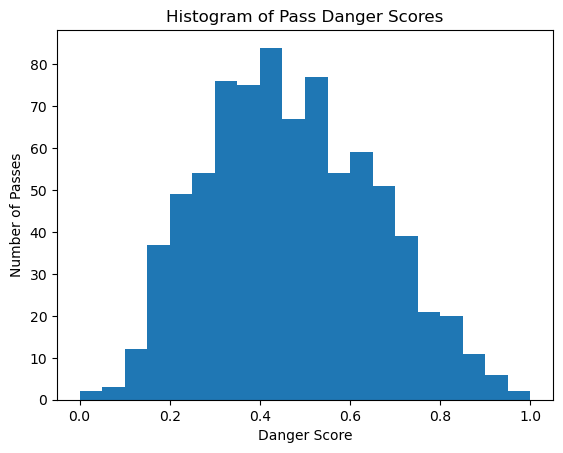

In [31]:
# visualisation du danger des passes par histogramme
import matplotlib.pyplot as plt

plt.hist(pass_with_tracking["danger_score"], bins=20)
plt.xlabel("Danger Score")
plt.ylabel("Number of Passes")
plt.title("Histogram of Pass Danger Scores")
plt.show()

In [32]:
df_final = pass_with_tracking[[
    "Period", "Team", "Start Time", "End Time",
    "From", "To",
    "Start X", "Start Y", "End X", "End Y",
    "progression", "angle", "distance_goal",
    "nearest_opponent", "count_2m", "count_6m",
    "speed", "eliminated",
    "danger_score"
]]

In [33]:
df_final.head()

,Period,Team,Start Time,End Time,From,To,Start X,Start Y,End X,End Y,progression,angle,distance_goal,nearest_opponent,count_2m,count_6m,speed,eliminated,danger_score
0,1,Away,0.04,0.12,Player19,Player21,0.45,0.39,0.55,0.43,-0.091187,-0.813717,0.554437,0.003625,1.0,2.0,1.346291,0.0,0.263339
1,1,Away,0.12,0.68,Player21,Player15,0.55,0.43,0.58,0.21,-0.094023,-0.259126,0.648460,0.129587,0.0,0.0,0.396493,0.0,0.268456
2,1,Away,1.80,2.44,Player15,Player19,0.55,0.19,0.45,0.31,0.142881,0.934895,0.488467,0.045860,0.0,1.0,0.244070,2.0,0.718418
3,1,Away,3.08,3.84,Player19,Player21,0.45,0.32,0.49,0.47,-0.006253,0.119615,0.490918,0.069988,0.0,0.0,0.204265,0.0,0.444070
4,1,Away,7.64,8.68,Player21,Player22,0.40,0.73,0.32,0.98,-0.115477,-0.210542,0.576888,0.100430,0.0,0.0,0.252392,2.0,0.353285


In [34]:
# on enregistre le dataframe final
df_final.to_csv("pass_features_danger_scores.csv", index=False)